In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
data = pd.read_csv('data/CrashData.csv')

# Define features and target
features = [
    'Driver_Action_Type_Cd', 'Speed_Before', 'Speed_Posted', 'Speed_Max_Safe',
    'Vehicle_Body_Type_Cd', 'Numberoflane', 'Carspeedlimit'
]
target = 'Crash_Severity'

C:\Users\Tao Groves\AppData\Local\Temp\ipykernel_44624\3719023213.py:1: DtypeWarning: Columns (47,49,51,53,63,64) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/CrashData.csv')


In [4]:
def split_string(string):
    # If the string is empty or nan, return an empty list
    if string == "" or pd.isnull(string):
        return []
    # Break down each string into a list if there is a semicolon
    if ";" in str(string):
        parts = string.split(";")
        return parts
    else:
        return [string]

def find_id(string):
    string = str(string).strip()
    result = ""
    for char in string:
        if char.isdigit():
            result += char
        elif char == ".":
            return result
        else:
            break
    return None

def clean_values(string):
    individual_strings: list = split_string(string)
    output: list = []
    for string in individual_strings:
        if find_id(string):
            output.append(find_id(string))
        else:
            output.append(string)
    return output

# Apply clean_values to all of the categorical columns
for column in data.columns:
    if data[column].dtype == "object":
        data[column] = data[column].apply(clean_values)

for column in data.columns:
    if data[column].dtype == "object":
        data[column] = data[column].apply(lambda x: x if type(x) != list else x[0] if len(x) > 0 else None)

categorical_vars = data.select_dtypes(include=['object']).columns.tolist()
print("Categorical variables:")
print(categorical_vars)

# Initialize the encoder
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()

# Encode categorical variables
data[categorical_vars] = data[categorical_vars].fillna('Missing')
data[categorical_vars] = encoder.fit_transform(data[categorical_vars])# Encode categorical values

# Drop rows with missing 'CRASH_SEVERITY'
data = data.dropna(subset=['Crash_Severity'])

# Identify numerical and categorical columns
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

# # Fill missing values
for col in numerical_cols:
    data[col] = data[col].fillna(data[col].mean())
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# One-Hot Encode categorical variables
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

Categorical variables:
['Crash_Severity', 'Driver_VehicleNumber', 'Driver_InjuryType', 'Driver_Age', 'Driver_Gender', 'Driver_Action_Type_Cd', 'Driver_Airbag_Deployment', 'Driver_Alcohol_Test_Type_Cd', 'Driver_Condition_Type_Cd', 'Driver_Distraction_Type_Cd', 'Driver_Drinking_Type_Cd', 'Driver_Drug_Use_Cd', 'Driver_Ejected_From_Vehicle', 'Driver_Ems_Transport_Ind', 'Driver_Fled_Scene_Ind', 'Driver_Safety_Equip_Used', 'Driver_Vis_Obscured_Type_Cd', 'Summons_Issued_Cd', 'Vehiclenumber', 'Vehicle_Body_Type_Cd', 'Vehicle_Make_Nm', 'Vehicle_Maneuver_Type_Cd', 'Vehicle_Model_Nm', 'Vehicle_Year_Nbr', 'Comm_Cargo_Body_Type_Cd', 'Comm_Vehicle_Body_Type_Cd', 'Speed_Before', 'Speed_Posted', 'Speed_Max_Safe', 'First_Crash_Event_Cd', 'Second_Crash_Event_Cd', 'Third_Crash_Event_Cd', 'Fourth_Crash_Event_Cd', 'Most_Harmful_Crash_Event_Cd', 'Initial_Veh_Impact_Area_Cd', 'Direction_Of_Travel_Cd', 'Pass_vehiclenumber', 'Pass_InjuryType', 'Pass_age', 'Pass_gender', 'Pass_Safety_Equip_Used', 'Pass_Airbag_D

In [17]:
# Preprocess the data
X = data[features].fillna(0)  # Replace NaN values with 0 (adjust as needed)
y = data[target]

# Encode categorical variables
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Normalize numerical data
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=features)

# Encode target variable
y = LabelEncoder().fit_transform(y)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
class AccidentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = AccidentDataset(X_train, y_train)
test_dataset = AccidentDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define the model
class AccidentSeverityModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super(AccidentSeverityModel, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.fc(x)

# Model setup
input_size = len(features)
num_classes = len(np.unique(y))
model = AccidentSeverityModel(input_size, num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the model
def train_model(model, train_loader, criterion, optimizer, epochs=10):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

# Evaluate the model
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")

In [11]:
# make sure gpu is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
criterion = criterion.to(device)
print(device)

train_model(model, train_loader, criterion, optimizer, epochs=3)

cpu
Epoch 1/3, Loss: 1.0225
Epoch 2/3, Loss: 1.0187
Epoch 3/3, Loss: 1.0169


In [12]:
evaluate_model(model, test_loader)

Test Accuracy: 0.6373


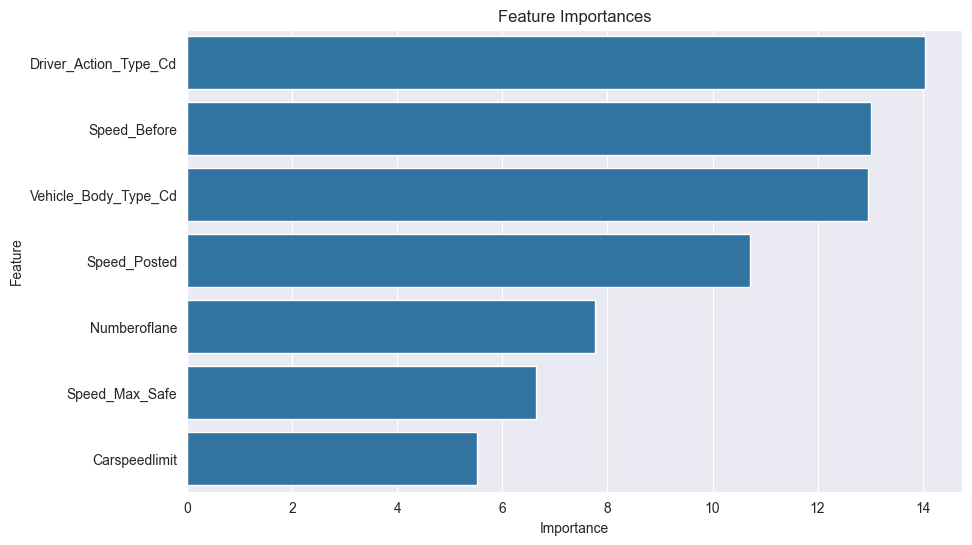

In [13]:
# extract the importance of each feature from the pytorch model
importance = model.fc[0].weight.data.abs().sum(dim=0)
feature_importance = pd.Series(importance.cpu().numpy(), index=features).sort_values(ascending=False)

# Visualize feature importances
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [22]:
# find which DRIVER_ACTION_TYPE_CD values are most likely to result in a severe crash
# Get the original labels for DRIVER_ACTION_TYPE_CD

# Get the weights for DRIVER_ACTION_TYPE_CD
action_weights = model.fc[0].weight.data[:, 0].cpu().numpy()

# Create a DataFrame with the action labels and weights
action_df = pd.DataFrame({'Action': range(len(action_weights)), 'Weight': action_weights})

# Sort the DataFrame by weight
action_df = action_df.sort_values('Weight', ascending=False)

# Display the top 10 actions
action_df.head(43)

,Action,Weight
29,29,0.750464
11,11,0.745438
30,30,0.630129
39,39,0.613941
23,23,0.559917
43,43,0.476747
13,13,0.366698
51,51,0.350898
8,8,0.334876
7,7,0.298047
